# Option Pricing Tool

Price options using:
- Classic non-calibrated Heston
- Classic Black-Scholes
- Classic calibrated Heston
- Neural network calibrated Heston

In [12]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import json

PROJECT_ROOT = Path("..")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.heston_model import HestonModel
from src.black_scholes_model import BlackScholesModel
from src.heston_calibrate_pan_ccn import load_pan_model, load_ccn_model, calibrate_with_pan_ccn

## Model Selection & Configuration


In [13]:
MODEL_TYPE = "classic_calibrated_heston"

CALIBRATED_PARAMS_PATH = "/Users/jorismrvy/Desktop/TBS MSc/Master Dissertation/Heston Model/data/results/calibration_results_20251121_144052.json"
PAN_MODEL_PATH = "/Users/jorismrvy/Desktop/TBS MSc/Master Dissertation/Heston Model/models/heston_pan_ccn/pan_model_scale_invariant.pth"
CCN_MODEL_PATH = "/Users/jorismrvy/Desktop/TBS MSc/Master Dissertation/Heston Model/models/heston_pan_ccn/ccn_model.pth"
MARKET_DATA_PATH = "/Users/jorismrvy/Desktop/TBS MSc/Master Dissertation/Heston Model/data/processed/calibration_data/qqq_calibration_data_20251121_192501.csv"

r = 0.04
q = 0.0
bs_sigma = 0.25

In [14]:
if MODEL_TYPE == "classic_heston":
    model = HestonModel(kappa=2.0, theta=0.04, sigma=0.3, rho=-0.7, v0=0.04, r=r, q=q)
elif MODEL_TYPE == "black_scholes":
    model = BlackScholesModel(sigma=bs_sigma, r=r, q=q)
elif MODEL_TYPE == "classic_calibrated_heston":
    with open(CALIBRATED_PARAMS_PATH, 'r') as f:
        calib_data = json.load(f)
    params = calib_data.get('parameters', calib_data)
    model = HestonModel(
        kappa=params['kappa'], theta=params['theta'], sigma=params['sigma'],
        rho=params['rho'], v0=params['v0'], r=params.get('r', r),
        q=params.get('q', q), lambd=params.get('lambd', 0.0)
    )
elif MODEL_TYPE == "nn_calibrated_heston":
    market_data = pd.read_csv(MARKET_DATA_PATH)
    S0_cal = market_data['spot'].iloc[0]
    calibration_input = pd.DataFrame({
        'strike': market_data['strike'].values,
        'tau': market_data['tau'].values,
        'price': market_data['mid_price'].values,
        'type': ['call'] * len(market_data)
    })
    pan_model = load_pan_model(PAN_MODEL_PATH)
    ccn_model = load_ccn_model(CCN_MODEL_PATH, input_dim=len(calibration_input))
    nn_params = calibrate_with_pan_ccn(
        market_prices=calibration_input, pan_model=pan_model, ccn_model=ccn_model,
        S0=S0_cal, r=r
    )
    model = HestonModel(
        kappa=nn_params['kappa'], theta=nn_params['theta'], sigma=nn_params['sigma'],
        rho=nn_params['rho'], v0=nn_params['v0'], r=r, q=q
    )
else:
    raise ValueError(f"Unknown model type: {MODEL_TYPE}")

print(f"Model: {MODEL_TYPE}")

Model: classic_calibrated_heston


## Single Contract Pricing


In [16]:
S0 = 603
K = 620
T_days = 3
T = T_days / 365.0
option_type = "call"

In [17]:
if isinstance(model, BlackScholesModel):
    price = model.option_price(S0, K, T, option_type)
    greeks = model.greeks(S0, K, T, option_type)
else:
    price = model.option_price(S0, K, T, option_type)
    greeks = model.compute_greeks(S0, K, T, option_type)

print(f"Price: ${price:.4f}")
print(f"Delta: {greeks['delta']:.4f}")
print(f"Gamma: {greeks['gamma']:.6f}")
print(f"Vega: {greeks['vega']:.4f}")
print(f"Theta: {greeks['theta']:.4f}")

Price: $1.0686
Delta: 0.1504
Gamma: 0.016167
Vega: 21.3588
Theta: -197.6088


## Visualization


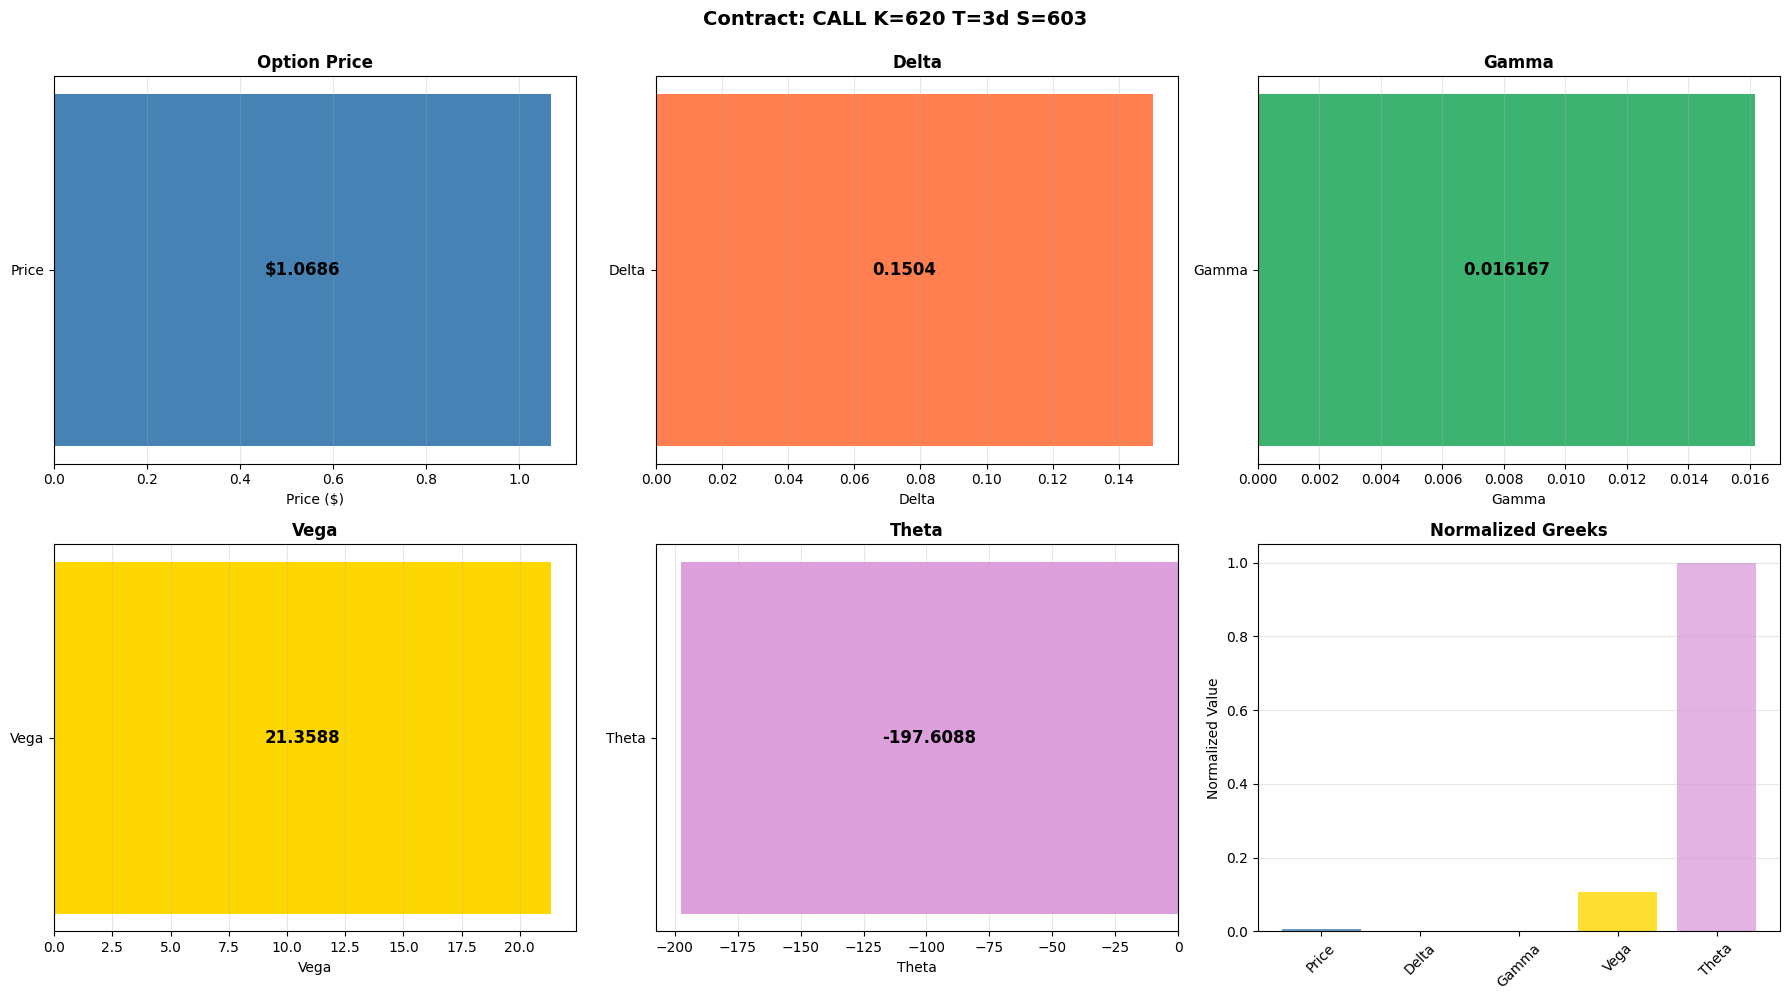

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

contract_label = f"{option_type.upper()} K={K} T={T_days}d S={S0}"

axes[0, 0].barh(['Price'], [price], color='steelblue')
axes[0, 0].set_title('Option Price', fontweight='bold')
axes[0, 0].set_xlabel('Price ($)')
axes[0, 0].grid(axis='x', alpha=0.3)
axes[0, 0].text(price/2, 0, f'${price:.4f}', ha='center', va='center', fontweight='bold', fontsize=12)

axes[0, 1].barh(['Delta'], [greeks['delta']], color='coral')
axes[0, 1].set_title('Delta', fontweight='bold')
axes[0, 1].set_xlabel('Delta')
axes[0, 1].grid(axis='x', alpha=0.3)
axes[0, 1].text(greeks['delta']/2, 0, f"{greeks['delta']:.4f}", ha='center', va='center', fontweight='bold', fontsize=12)

axes[0, 2].barh(['Gamma'], [greeks['gamma']], color='mediumseagreen')
axes[0, 2].set_title('Gamma', fontweight='bold')
axes[0, 2].set_xlabel('Gamma')
axes[0, 2].grid(axis='x', alpha=0.3)
axes[0, 2].text(greeks['gamma']/2, 0, f"{greeks['gamma']:.6f}", ha='center', va='center', fontweight='bold', fontsize=12)

axes[1, 0].barh(['Vega'], [greeks['vega']], color='gold')
axes[1, 0].set_title('Vega', fontweight='bold')
axes[1, 0].set_xlabel('Vega')
axes[1, 0].grid(axis='x', alpha=0.3)
axes[1, 0].text(greeks['vega']/2, 0, f"{greeks['vega']:.4f}", ha='center', va='center', fontweight='bold', fontsize=12)

axes[1, 1].barh(['Theta'], [greeks['theta']], color='plum')
axes[1, 1].set_title('Theta', fontweight='bold')
axes[1, 1].set_xlabel('Theta')
axes[1, 1].grid(axis='x', alpha=0.3)
axes[1, 1].text(greeks['theta']/2, 0, f"{greeks['theta']:.4f}", ha='center', va='center', fontweight='bold', fontsize=12)

greek_names = ['Price', 'Delta', 'Gamma', 'Vega', 'Theta']
greek_values = [price, greeks['delta'], greeks['gamma'], greeks['vega'], greeks['theta']]
greek_values_abs = [abs(v) for v in greek_values]
max_val = max(greek_values_abs) if max(greek_values_abs) > 0 else 1
greek_values_norm = [v / max_val for v in greek_values_abs]

colors = ['steelblue', 'coral', 'mediumseagreen', 'gold', 'plum']
axes[1, 2].bar(greek_names, greek_values_norm, color=colors, alpha=0.8)
axes[1, 2].set_title('Normalized Greeks', fontweight='bold')
axes[1, 2].set_ylabel('Normalized Value')
axes[1, 2].tick_params(axis='x', rotation=45)
axes[1, 2].grid(axis='y', alpha=0.3)

plt.suptitle(f'Contract: {contract_label}', fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

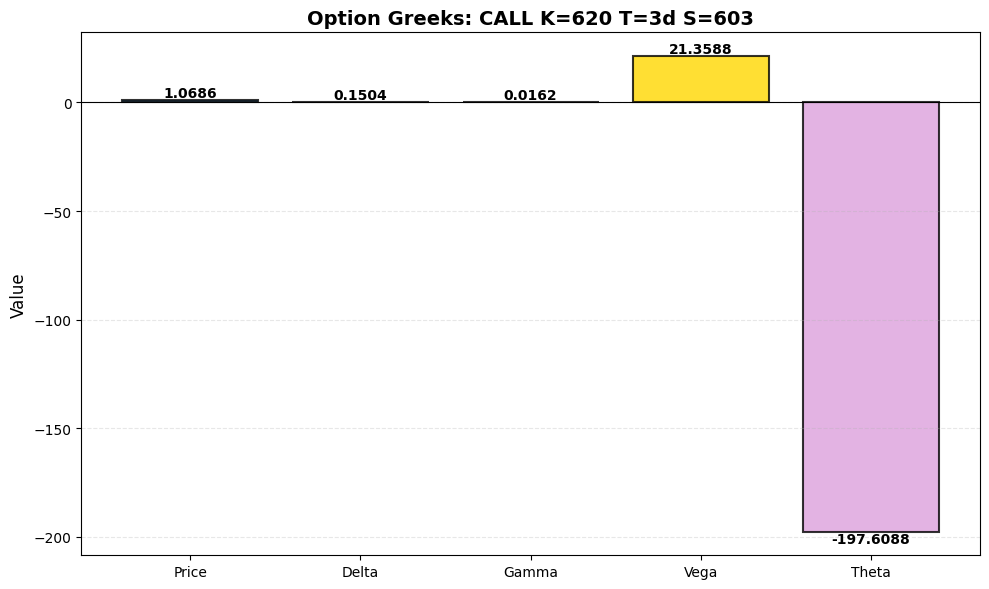

In [19]:
fig, ax = plt.subplots(figsize=(10, 6))

greek_names = ['Price', 'Delta', 'Gamma', 'Vega', 'Theta']
greek_values = [price, greeks['delta'], greeks['gamma'], greeks['vega'], greeks['theta']]
colors = ['steelblue', 'coral', 'mediumseagreen', 'gold', 'plum']

bars = ax.bar(greek_names, greek_values, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)

for i, (name, val) in enumerate(zip(greek_names, greek_values)):
    ax.text(i, val, f'{val:.4f}', ha='center', va='bottom' if val >= 0 else 'top', 
            fontweight='bold', fontsize=10)

ax.axhline(0, color='black', linestyle='-', linewidth=0.8)
ax.set_ylabel('Value', fontsize=12)
ax.set_title(f'Option Greeks: {contract_label}', fontweight='bold', fontsize=14)
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()